In [ ]:
Vinix_Analyze_Dataset.ipynb




# Titanic Dataset Analysis

## Introduction

This project focuses on analyzing the Titanic dataset using Python and data analysis libraries. The purpose of this analysis is to explore the data, identify patterns, and understand which passenger characteristics were related to survival.

The analysis includes passenger demographics, gender, passenger class, age, fare, and embarkation location. Different charts and statistical methods are used to present the findings clearly.


## Dataset Description

The Titanic dataset contains information about passengers who traveled on the Titanic.

### Main Features

* **Survived:** Whether the passenger survived (0 = No, 1 = Yes)
* **Pclass:** Passenger class (1st, 2nd, or 3rd)
* **Sex:** Passenger gender
* **Age:** Passenger age
* **SibSp:** Number of siblings or spouses aboard
* **Parch:** Number of parents or children aboard
* **Fare:** Passenger ticket fare
* **Embarked:** Port where the passenger boarded

The dataset contains **891 rows and 15 columns**.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading and Initial Exploration

The required Python libraries were imported and the Titanic dataset was loaded for analysis.


In [6]:
df = sns.load_dataset("titanic")

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.shape


(891, 15)

## Dataset Overview

The dataset contains **891 passenger records and 15 columns**. It includes numerical, categorical, and Boolean features related to passengers, their tickets, and survival status.

Before performing the analysis, the structure and data types of the dataset were examined using the `info()` function.


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Missing Values

The dataset was checked for missing values to understand the completeness of the data. This step helps identify columns that may require data cleaning before further analysis.


In [31]:
# Check missing values
df.isnull().sum()


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [10]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df.shape

(891, 15)



## Survival Analysis

The survival status of the passengers was analyzed to determine how many passengers survived and how many did not.


In [32]:
# Count survived and non-survived passengers
df["survived"].value_counts()

,count
survived,
0,549
1,342


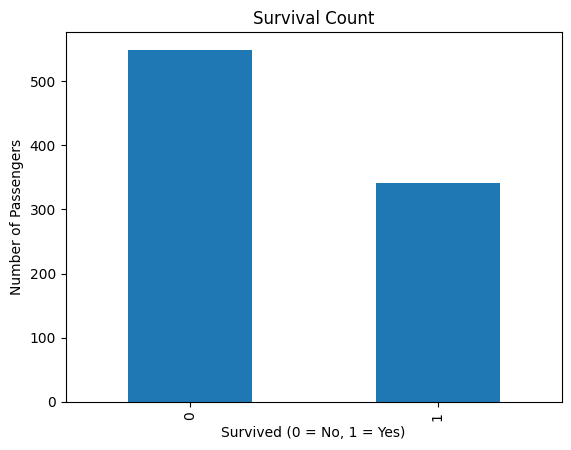

In [14]:
df["survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

## Survival by Gender

The survival rate was compared between male and female passengers to identify whether gender was associated with survival.


In [17]:
pd.crosstab(df["sex"], df["survived"])

survived,0,1
sex,,
female,81,233
male,468,109


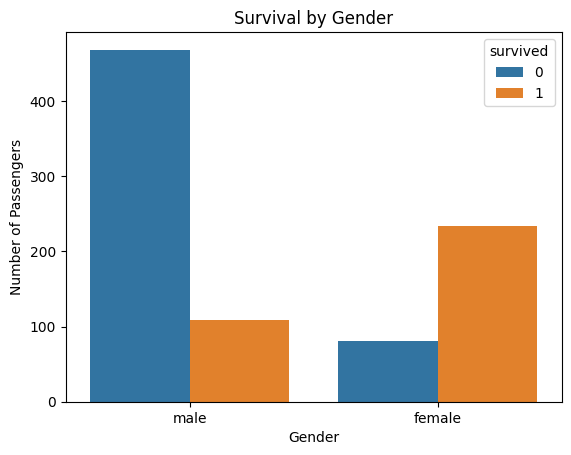

In [16]:
sns.countplot(data=df, x="sex", hue="survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

In [18]:
df.groupby("sex")["survived"].mean() * 100

,survived
sex,
female,74.203822
male,18.890815


## Survival by Passenger Class

The survival rate was analyzed across different passenger classes to determine whether passenger class was related to survival.


In [19]:
pd.crosstab(df["pclass"], df["survived"])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


In [20]:
df.groupby("pclass")["survived"].mean() * 100

,survived
pclass,
1,62.962963
2,47.282609
3,24.236253


## Age Analysis

The age distribution of passengers was examined to understand the general age range of people traveling on the Titanic.


In [21]:
df["age"].mean()

np.float64(29.69911764705882)

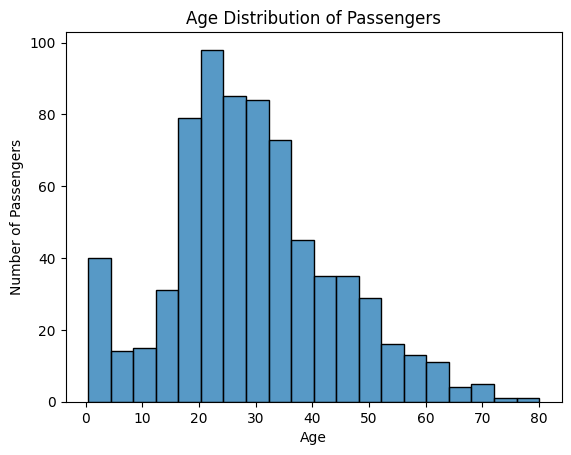

In [22]:
sns.histplot(data=df, x="age", bins=20)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

## Fare Analysis

The ticket fare was analyzed to compare the average fare paid by passengers who survived and those who did not.


In [23]:
df["fare"].describe()

,fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [24]:
df.groupby("survived")["fare"].mean()

,fare
survived,
0,22.117887
1,48.395408


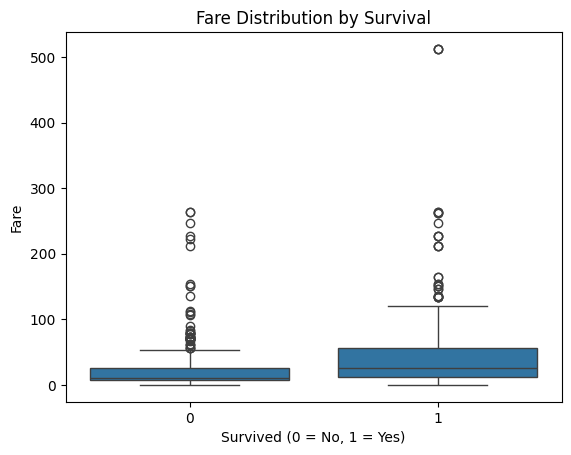

In [25]:
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

## Survival by Embarkation Location

The passengers were also analyzed based on the town where they boarded the Titanic. This helps compare the number of passengers and their survival rates across different embarkation locations.



In [27]:
df["embark_town"].value_counts()

,count
embark_town,
Southampton,644
Cherbourg,168
Queenstown,77


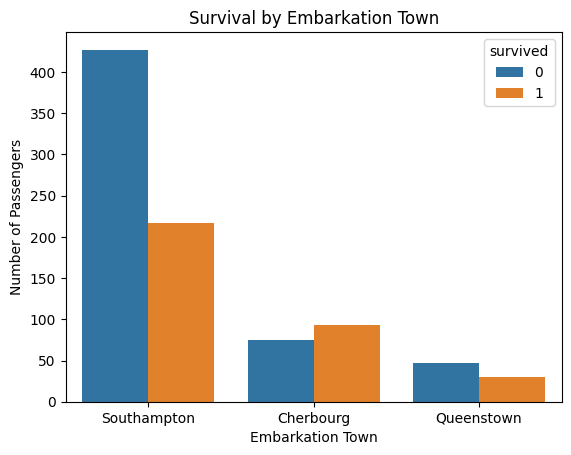

In [28]:
sns.countplot(data=df, x="embark_town", hue="survived")
plt.title("Survival by Embarkation Town")
plt.xlabel("Embarkation Town")
plt.ylabel("Number of Passengers")
plt.show()

## Combined Survival Analysis

The relationship between passenger class, gender, and survival was further explored to identify combined patterns in the dataset.


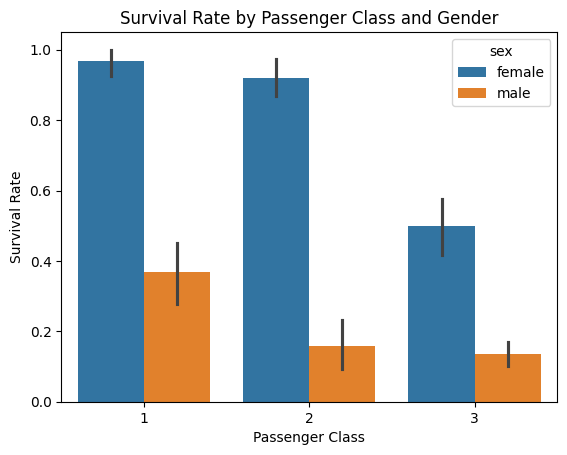

In [33]:
# Compare survival rate by passenger class and gender
sns.barplot(data=df, x="pclass", y="survived", hue="sex")

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [29]:
df.groupby("embark_town")["survived"].mean() * 100

,survived
embark_town,
Cherbourg,55.357143
Queenstown,38.961039
Southampton,33.695652


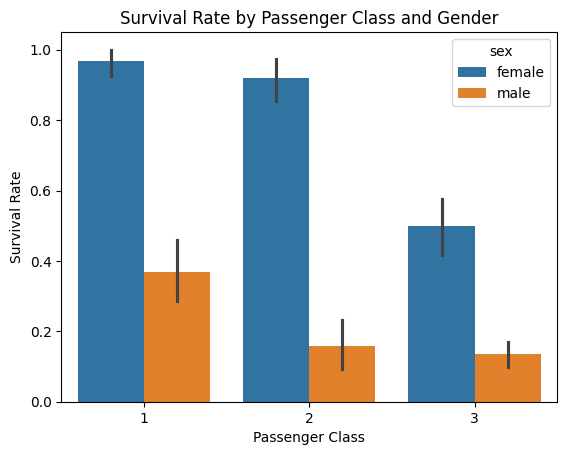

In [30]:
sns.barplot(data=df, x="pclass", y="survived", hue="sex")

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

## Key Findings

1. The dataset contains **891 passengers** and **15 columns**.

2. **342 passengers survived**, while **549 passengers did not survive**. The overall survival rate was approximately **38.4%**.

3. **Gender had a strong relationship with survival.** The survival rate was **74.20% for females** compared with **18.89% for males**.

4. **Passenger class was also associated with survival.** The survival rate was **62.96% for 1st class**, **47.28% for 2nd class**, and **24.24% for 3rd class**.

5. The **average passenger age was approximately 29.7 years**.

6. The average fare for passengers who survived was **48.40**, compared with **22.12** for passengers who did not survive.

7. Most passengers (**644**) embarked from **Southampton**. However, **Cherbourg had the highest survival rate at 55.36%**.

8. The dataset contains missing values, particularly in the **age** and **deck** columns. These missing values were identified but not modified because data cleaning is a separate task.


## Conclusion

The Titanic dataset analysis shows that survival was associated with several passenger characteristics. Female passengers had a considerably higher survival rate than male passengers. Passengers in higher classes also had higher survival rates than those in lower classes. In addition, passengers who survived generally paid higher fares.

The analysis also identified missing values in some columns, which should be handled carefully during the data-cleaning stage. Overall, this dataset provides useful insights into how different passenger characteristics were related to survival.
